# 08 — Income nonresponse by employment status

A note up front on what BRFSS actually contains. **There is no occupation or industry
variable in the BRFSS public-use files.** The NIOSH-sponsored Industry & Occupation
module collects free-text job titles, but the coded results are restricted (released
through NIOSH, not in the annual PUF), and a scan of every year here (2011–2023) finds
no occupation/industry field. The closest available dimension of labor-market position
is **employment status** (`EMPLOY1`, or `EMPLOY` in 2011) — and it does carry an
occupational-class signal, most directly in the **self-employed vs employed-for-wages**
contrast (business owners vs employees), alongside retired, out-of-work, homemaker,
student, and unable-to-work.

So this notebook extends the refused-vs-don't-know story to employment status. **Read
it as labor-market position, not occupation**, and bear two confounds in mind:
employment status is partly *downstream* of income itself, and it is entangled with age
(retirement) and health (unable to work). We keep Refused (99) and Don't know (77)
distinct, condition on respondents asked the income item, and weight every estimate.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import multiyear as my

DATA = os.path.abspath(os.path.join('..', 'data'))
RAW = os.path.join(DATA, 'raw', 'brfss')
DERIVED = os.path.join(DATA, 'derived')

df = my.load_all(RAW)
df = df[df['income_asked'] & df['employ'].notna()].copy()
print('respondents (asked income, employment known):', len(df))
order = my.EMPLOY_ORDER
nice = {'Employed': 'Employed\n(wages)', 'Self-employed': 'Self-\nemployed',
        'OutOfWork': 'Out of\nwork', 'Homemaker': 'Home-\nmaker', 'Student': 'Student',
        'Retired': 'Retired', 'Unable': 'Unable\nto work'}
print(df.groupby('year')['employ'].count())

respondents (asked income, employment known): 3550744
year
2011    503313
2013    488185
2015    434737
2017    443139
2019    407890
2021    425385
2022    427379
2023    420716
Name: employ, dtype: int64


## The cross-section (2023): who refuses, who says don't know?

Survey-weighted share refusing vs saying don't know, by employment status.

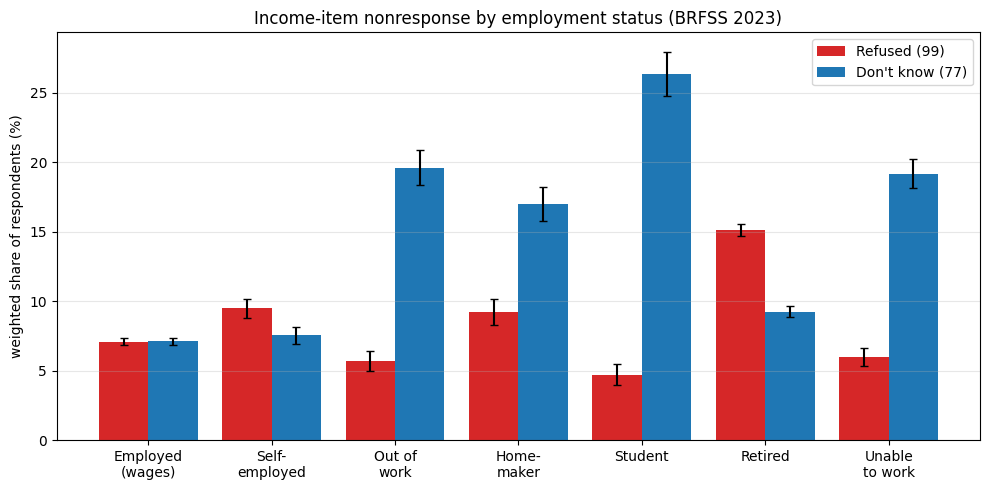

,refused_%,dk_%
employ,,
Employed,7.1,7.1
Self-employed,9.5,7.5
OutOfWork,5.7,19.6
Homemaker,9.2,17.0
Student,4.7,26.4
Retired,15.1,9.3
Unable,6.0,19.2


In [2]:
d23 = df[df['year'] == 2023]
gr = my.wprop(d23, 'refused', by='employ').set_index('employ').reindex(order)
gd = my.wprop(d23, 'dk', by='employ').set_index('employ').reindex(order)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, 100*gr['p'], 0.4, yerr=100*1.96*gr['se'], capsize=3, label='Refused (99)', color='C3')
ax.bar(x + 0.2, 100*gd['p'], 0.4, yerr=100*1.96*gd['se'], capsize=3, label="Don't know (77)", color='C0')
ax.set_xticks(x); ax.set_xticklabels([nice[o] for o in order])
ax.set_ylabel('weighted share of respondents (%)')
ax.set_title('Income-item nonresponse by employment status (BRFSS 2023)')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()
pd.DataFrame({'refused_%': (100*gr['p']).round(1), 'dk_%': (100*gd['p']).round(1)})

## The occupational-class contrast: self-employed vs employed-for-wages, over time

The sharpest "class" cut available here. Do business owners guard their income
differently from wage employees, and has the gap moved across 2011–2023?

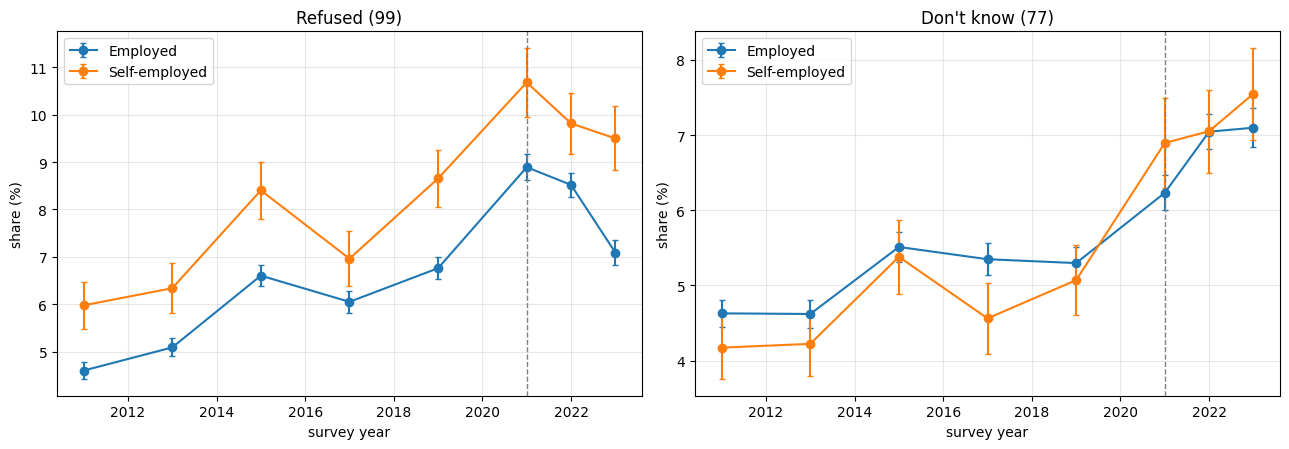

In [3]:
sub = df[df['employ'].isin(['Self-employed', 'Employed'])].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
for flag, ax, ttl in [('refused', axes[0], 'Refused (99)'), ('dk', axes[1], "Don't know (77)")]:
    g = my.wprop(sub, flag, by=['year', 'employ'])
    for cat, c in [('Employed', 'C0'), ('Self-employed', 'C1')]:
        s = g[g['employ'] == cat].sort_values('year')
        ax.errorbar(s['year'], 100*s['p'], yerr=100*1.96*s['se'], marker='o', capsize=2,
                    color=c, label=cat)
    ax.axvline(2021, color='gray', ls='--', lw=1)
    ax.set_xlabel('survey year'); ax.set_ylabel('share (%)'); ax.set_title(ttl)
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Pooled ranking (2011–2023)

Pooling years for a stable ranking of nonresponse by employment status.

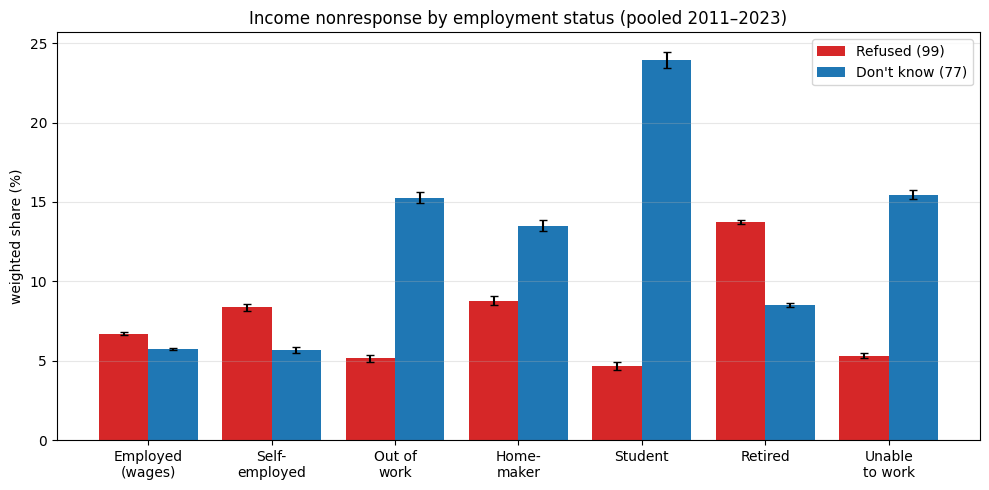

In [4]:
gr_all = my.wprop(df, 'refused', by='employ').set_index('employ').reindex(order)
gd_all = my.wprop(df, 'dk', by='employ').set_index('employ').reindex(order)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, 100*gr_all['p'], 0.4, yerr=100*1.96*gr_all['se'], capsize=3, label='Refused (99)', color='C3')
ax.bar(x + 0.2, 100*gd_all['p'], 0.4, yerr=100*1.96*gd_all['se'], capsize=3, label="Don't know (77)", color='C0')
ax.set_xticks(x); ax.set_xticklabels([nice[o] for o in order])
ax.set_ylabel('weighted share (%)'); ax.set_title('Income nonresponse by employment status (pooled 2011–2023)')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

out = []
for flag in ['refused', 'dk']:
    t = my.wprop(df, flag, by=['year', 'employ']); t['flag'] = flag; out.append(t)
pd.concat(out).to_csv(os.path.join(DERIVED, 'brfss_income_nonresponse_by_employ.csv'), index=False)

## Summary numbers

In [5]:
print('2023, weighted share refusing / saying don\'t know, by employment status:')
for o in order:
    print(f"  {o:13s} refused {100*gr.loc[o,'p']:4.1f}%   dk {100*gd.loc[o,'p']:4.1f}%")
se_emp = gr.loc['Self-employed', 'p']; emp = gr.loc['Employed', 'p']
print(f"\nSelf-employed refuse income at {100*se_emp:.1f}% vs {100*emp:.1f}% for wage "
      f"employees in 2023 (ratio {se_emp/emp:.2f}x).")

2023, weighted share refusing / saying don't know, by employment status:
  Employed      refused  7.1%   dk  7.1%
  Self-employed refused  9.5%   dk  7.5%
  OutOfWork     refused  5.7%   dk 19.6%
  Homemaker     refused  9.2%   dk 17.0%
  Student       refused  4.7%   dk 26.4%
  Retired       refused 15.1%   dk  9.3%
  Unable        refused  6.0%   dk 19.2%

Self-employed refuse income at 9.5% vs 7.1% for wage employees in 2023 (ratio 1.34x).


## Interpretation

**The two mechanisms split along familiar lines — privacy vs uncertainty.** In 2023,
refusal is highest among the **retired (15.1%)** and the **self-employed (9.5%)** —
groups with assets, a business, or a life stage that makes income a private matter —
while don't-know is highest among **students (26.4%)**, the **out-of-work (19.6%)**,
those **unable to work (19.2%)**, and **homemakers (17.0%)** — people often dependent on
or uncertain about *household* income. **Employed-for-wages** respondents sit lowest and
perfectly balanced (7.1% / 7.1%): they know their paycheck and report it. Exactly as
with education (notebook 02), refused and don't-know trace *different* maps of social
position, so collapsing them throws away signal.

**The occupational-class contrast — self-employed vs employed — is real and durable.**
The self-employed refuse about a third more often than wage employees (9.5% vs 7.1% in
2023), and that premium is strikingly stable across the whole 2011–2023 window
(self-employed/employed refusal ratio 1.15–1.34 every year) even as the overall level of
refusal climbed. Business owners consistently guard their income more than employees do
— the clearest "class" signal the public file can give.

**Read it as labor-market position, not occupation — and mind the confounds.** BRFSS
carries no occupation code, so employment status is the available proxy, and it is
entangled with dimensions seen elsewhere: "retired" overlaps the older, higher-refusal
cohorts of notebook 07; "student" / "out of work" / "unable" overlap youth, low income,
and poor health; and employment status is itself partly *downstream* of income. These
are descriptions of who declines, not clean causal effects of job type.

**Why it matters for the modeling.** Like education and cohort, employment status shows
refusal concentrated in higher-resource / privacy groups and don't-know in dependent /
uncertain ones — the same opposite-direction signature that justifies keeping the two
codes distinct and giving refusal its own one-directional MNAR treatment in model C.